In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
file_path = "ansur_male.csv"  # Update if needed

# Try different encodings
try:
    df = pd.read_csv(file_path, encoding="utf-8")  # Default
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="ISO-8859-1")  # Common fix
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="latin1")  # Alternative fix
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding="cp1252")  # Windows encoding

In [3]:
# Display first few rows

print(df.head(10))

   subjectid  abdominalextensiondepthsitting  acromialheight  \
0      10027                             266            1467   
1      10032                             233            1395   
2      10033                             287            1430   
3      10092                             234            1347   
4      10093                             250            1585   
5      10115                             263            1407   
6      10117                             314            1476   
7      10237                             304            1529   
8      10242                             321            1457   
9      10244                             227            1481   

   acromionradialelength  anklecircumference  axillaheight  \
0                    337                 222          1347   
1                    326                 220          1293   
2                    341                 230          1327   
3                    310                 230   

In [6]:

print(f"info:{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4082 entries, 0 to 4081
Columns: 108 entries, subjectid to WritingPreference
dtypes: int64(99), object(9)
memory usage: 3.4+ MB
info:None


## Detect outlier / anamolies based on 1 column

In [7]:
# On 1 columns

# Choose a numerical column
column = 'abdominalextensiondepthsitting'  # Example: height in meters (adjust based on dataset)

# Convert to a DataFrame (KNN needs 2D input)
X = df[[column]].dropna()  # Drop NaN values if any

# KNN Model
k = 50  # Number of neighbors
model = NearestNeighbors(n_neighbors=k)
model.fit(X)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [11]:
# Compute the distance to the k-nearest neighbors

distances, indices = model.kneighbors(X)
print(distances.shape) # rows=data-points, columns=k-neighbors
print(distances[0])


print(indices)

(4082, 50)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
[[4037 3782 4051 ...  199  322  799]
 [3513 3534 3763 ... 2791 2706 2019]
 [3762 2933 3067 ... 1235  617 1709]
 ...
 [3957 3976 3770 ... 1270  581 1375]
 [2229 2649 4080 ... 1522  716 2807]
 [4081 3915 3533 ... 1922 2460 2044]]


In [19]:
avg_distances = distances.mean(axis=1)  # Mean distance to k-nearest neighbors

print(type(avg_distances))
print(avg_distances.shape) # Number of data points
print("Average distance of 1st point: ", avg_distances[0])
print("Average distance of 3rd point: ", avg_distances[2])

<class 'numpy.ndarray'>
(4082,)
Average distance of 1st point:  0.2
Average distance of 3rd point:  0.3


In [15]:
# Set an outlier threshold (e.g., top 1% or 5% , etc highest distances)

threshold = np.percentile(avg_distances, 99)
print("Threshold:", threshold) # 99% of average distance is below this value

6.52


In [20]:
# Lets create a new column knn_outlier that is True if avg_distances > threshold, else False
df["knn_outlier"] = False  # initialize
df.loc[X.index, "knn_outlier"] = avg_distances > threshold

print(df.sample(10))

      subjectid  abdominalextensiondepthsitting  acromialheight  \
1000      14205                             255            1485   
245       11265                             298            1505   
2511      23810                             201            1474   
1709      15979                             288            1512   
74        10616                             322            1514   
2681      25007                             303            1522   
2921      27007                             219            1472   
2990      27173                             271            1439   
3439      28069                             201            1479   
2785      26714                             239            1431   

      acromionradialelength  anklecircumference  axillaheight  \
1000                    355                 203          1357   
245                     343                 253          1395   
2511                    361                 216          1372   
17

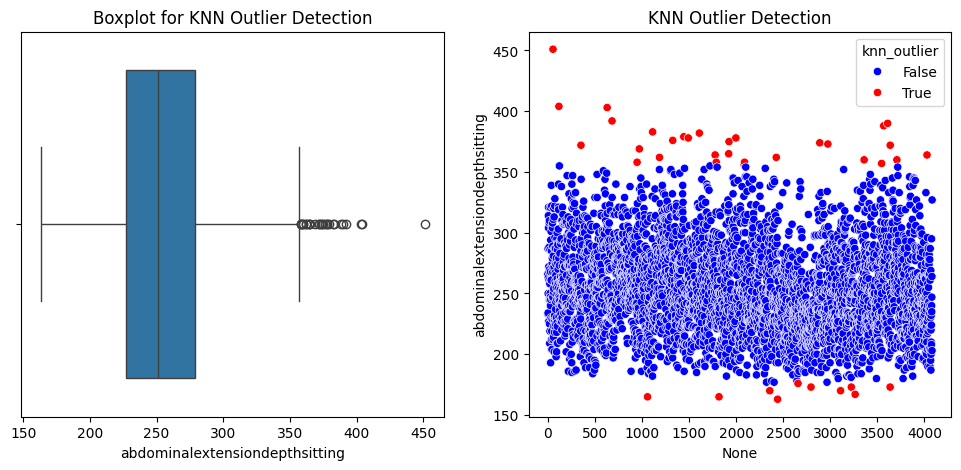

KNN Outliers Detected: 40


In [21]:
# Plot results
plt.figure(figsize=(12, 5))

# Boxplot for outliers
plt.subplot(1, 2, 1)
sns.boxplot(x=df[column])
plt.title("Boxplot for KNN Outlier Detection")

# Scatter plot showing outliers
plt.subplot(1, 2, 2)
sns.scatterplot(x=df.index, y=df[column], hue=df['knn_outlier'], palette={True: "red", False: "blue"})
plt.title("KNN Outlier Detection")

plt.show()

# Print summary
print(f"KNN Outliers Detected: {df['knn_outlier'].sum()}")


## Detect outlier / anamolies based on > 1 column

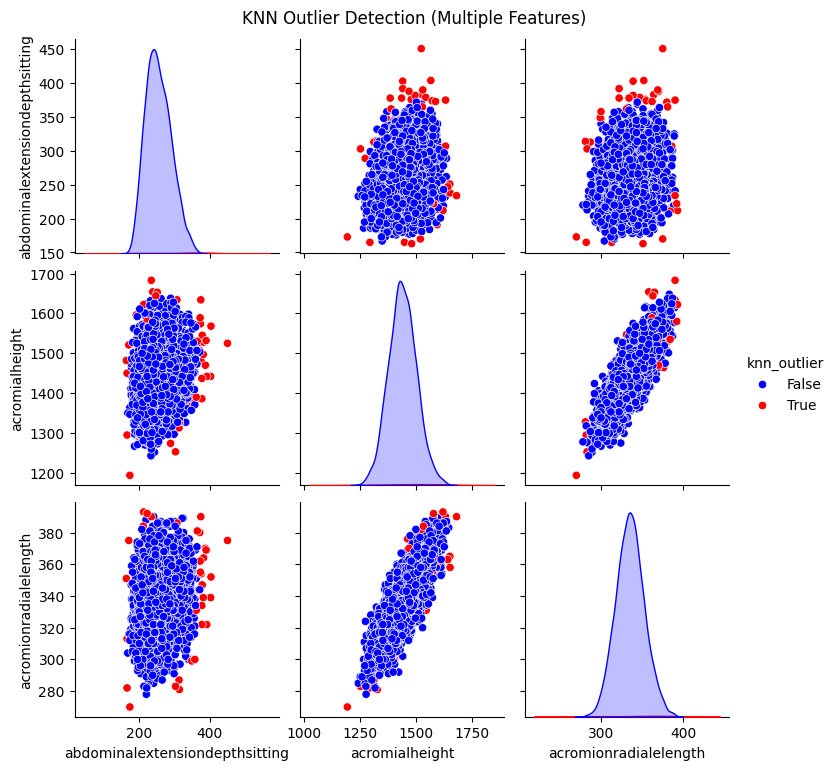

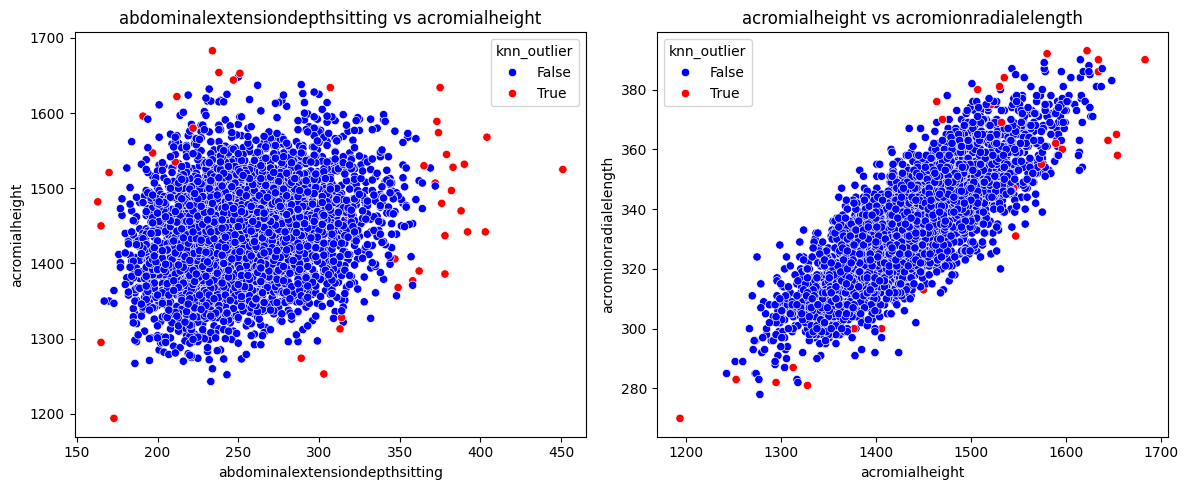

KNN Outliers Detected: 41
###############
      abdominalextensiondepthsitting  acromialheight  acromionradialelength  \
55                               451            1525                    375   
118                              404            1568                    352   
205                              347            1406                    300   
352                              372            1507                    380   
625                              349            1368                    299   
630                              403            1442                    339   
682                              392            1442                    322   
776                              289            1274                    296   
906                              318            1464                    376   
948                              358            1377                    300   
964                              313            1313                    287   
1059      

In [6]:
# On > 1 column

# Select numerical columns (adjust based on dataset)
features = ['abdominalextensiondepthsitting', 'acromialheight', 'acromionradialelength']  # Replace with real column names
df_selected = df[features].dropna()

# Scale data (KNN performs better with standardized data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)

# KNN Model
k = 15  # Number of neighbors
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X_scaled)

# Compute mean distance to k-nearest neighbors
distances, indices = nbrs.kneighbors(X_scaled)
avg_distances = distances.mean(axis=1)

# Set an outlier threshold (top 1% or 5% highest distances)
threshold = np.percentile(avg_distances, 99)
df_selected['knn_outlier'] = avg_distances > threshold

# Pairplot for multiple features (outliers in red)
sns.pairplot(df_selected, hue='knn_outlier', palette={True: "red", False: "blue"})
plt.suptitle("KNN Outlier Detection (Multiple Features)", y=1.02)
plt.show()

# Scatter plots for 2D visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=df_selected[features[0]], y=df_selected[features[1]], 
                hue=df_selected['knn_outlier'], palette={True: "red", False: "blue"}, ax=axes[0])
axes[0].set_title(f"{features[0]} vs {features[1]}")

sns.scatterplot(x=df_selected[features[1]], y=df_selected[features[2]], 
                hue=df_selected['knn_outlier'], palette={True: "red", False: "blue"}, ax=axes[1])
axes[1].set_title(f"{features[1]} vs {features[2]}")

plt.tight_layout()
plt.show()

# Print summary
print(f"KNN Outliers Detected: {df_selected['knn_outlier'].sum()}")
print("###############")
# Print all detected outliers
df_outliers = df_selected[df_selected['knn_outlier']]
print(df_outliers)

## Lets detect outliers using pyod package
We will detect on only 5 columns because this is computationally expensive process.

In [22]:
from pyod.models.knn import KNN  # KNN-based anomaly detection

# Automatically select all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# numeric_cols = ['abdominalextensiondepthsitting', 'acromialheight', 'acromionradialelength'] # or you can specify here

print(numeric_cols)

['subjectid', 'abdominalextensiondepthsitting', 'acromialheight', 'acromionradialelength', 'anklecircumference', 'axillaheight', 'balloffootcircumference', 'balloffootlength', 'biacromialbreadth', 'bicepscircumferenceflexed', 'bicristalbreadth', 'bideltoidbreadth', 'bimalleolarbreadth', 'bitragionchinarc', 'bitragionsubmandibulararc', 'bizygomaticbreadth', 'buttockcircumference', 'buttockdepth', 'buttockheight', 'buttockkneelength', 'buttockpopliteallength', 'calfcircumference', 'cervicaleheight', 'chestbreadth', 'chestcircumference', 'chestdepth', 'chestheight', 'crotchheight', 'crotchlengthomphalion', 'crotchlengthposterioromphalion', 'earbreadth', 'earlength', 'earprotrusion', 'elbowrestheight', 'eyeheightsitting', 'footbreadthhorizontal', 'footlength', 'forearmcenterofgriplength', 'forearmcircumferenceflexed', 'forearmforearmbreadth', 'forearmhandlength', 'functionalleglength', 'handbreadth', 'handcircumference', 'handlength', 'headbreadth', 'headcircumference', 'headlength', 'heel

In [24]:
# Set a limit for the number of numeric columns to use
# If you use all columns, then this could take long time: > 10 minutes
num_features_limit = 5  # Change this to the desired number of features

# Select only the first `num_features_limit` numeric columns
numeric_cols = numeric_cols[0:num_features_limit+1]
print(numeric_cols)

['abdominalextensiondepthsitting', 'acromialheight', 'acromionradialelength', 'anklecircumference', 'axillaheight']


In [26]:
# Specify columns to drop (modify if needed)
drop_cols = ['subjectid', 'DODRace', 'SubjectNumericRace']  # Example: ['id', 'unnecessary_column']

# Filter out columns to drop
numeric_cols = [col for col in numeric_cols if col not in drop_cols]
print(f"Using first {num_features_limit} numeric columns: {numeric_cols}")

# Ensure we have numeric columns to process
if not numeric_cols:
    raise ValueError("No numeric columns available after dropping the specified columns!")


Using first 5 numeric columns: ['abdominalextensiondepthsitting', 'acromialheight', 'acromionradialelength', 'anklecircumference', 'axillaheight']


In [29]:
# Select only numeric data
df_selected = df[numeric_cols].dropna()

In [30]:
# Standardize features (KNN works better on normalized data)
scaler = StandardScaler()

scaler.fit(df_selected)
X_scaled = scaler.transform(df_selected)
# X_scaled = scaler.fit_transform(df_selected)


Detected Outliers:
       abdominalextensiondepthsitting  acromialheight  acromionradialelength  \
23                               219            1624                    388   
55                               451            1525                    375   
118                              404            1568                    352   
192                              289            1483                    318   
256                              340            1379                    300   
352                              372            1507                    380   
484                              268            1424                    292   
612                              332            1327                    302   
625                              349            1368                    299   
630                              403            1442                    339   
682                              392            1442                    322   
776                             

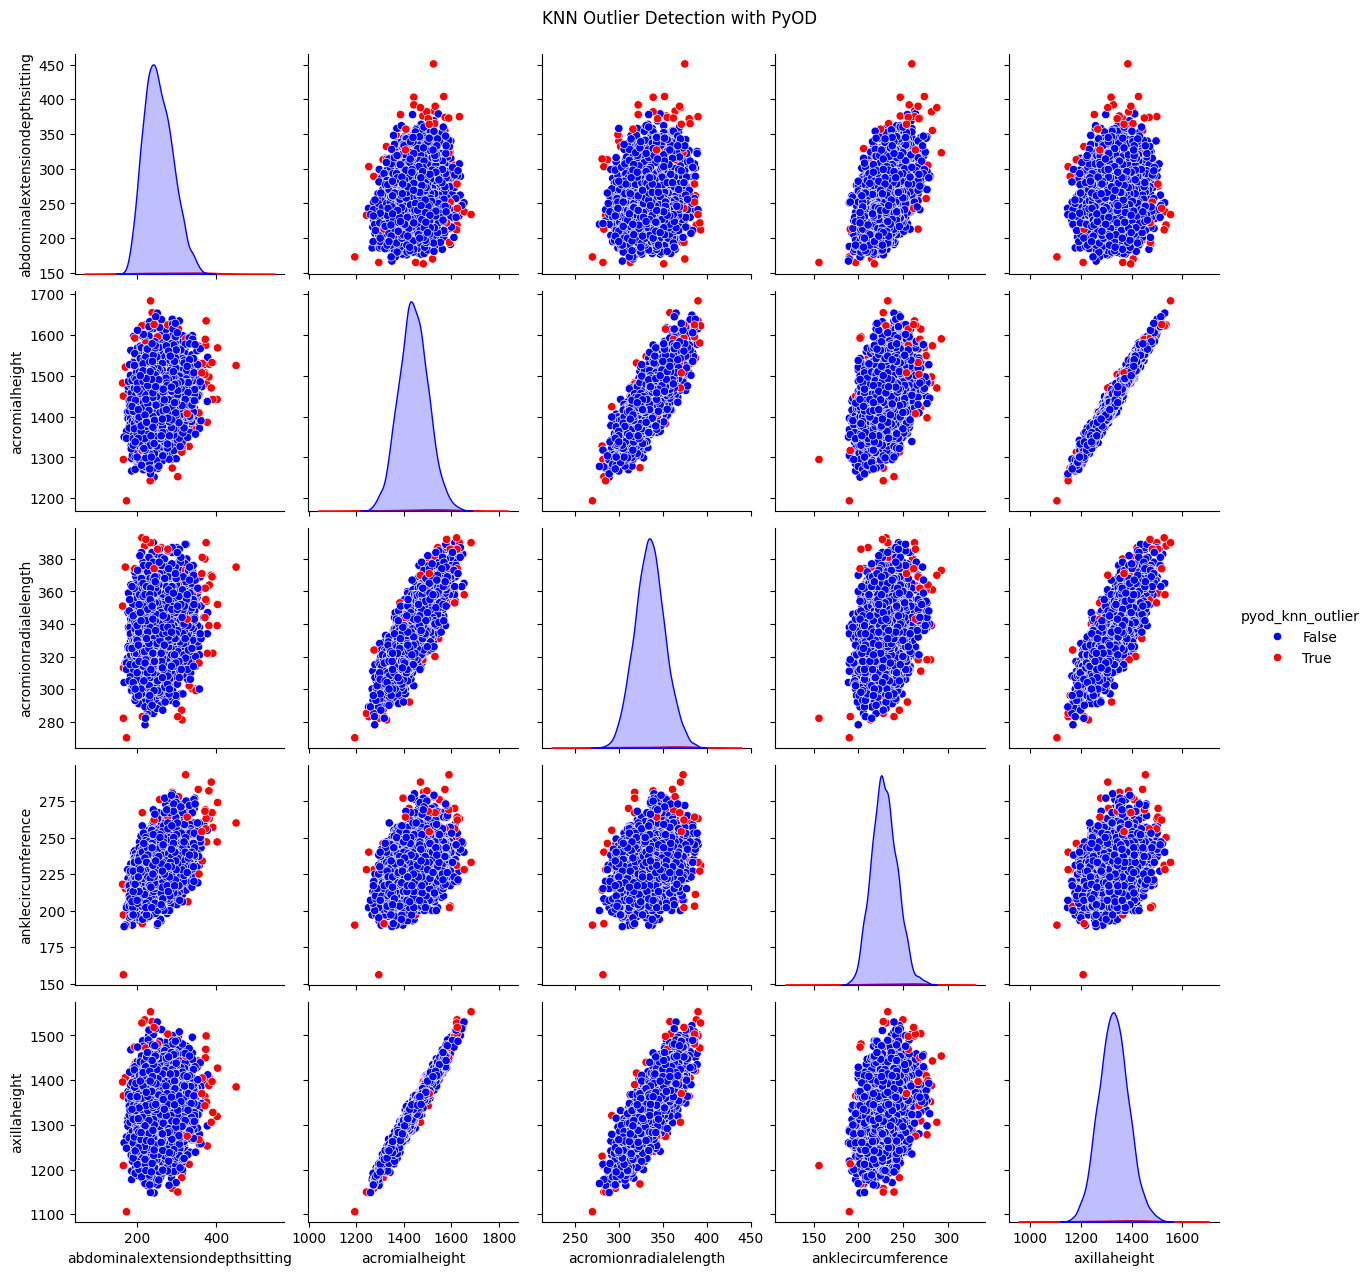

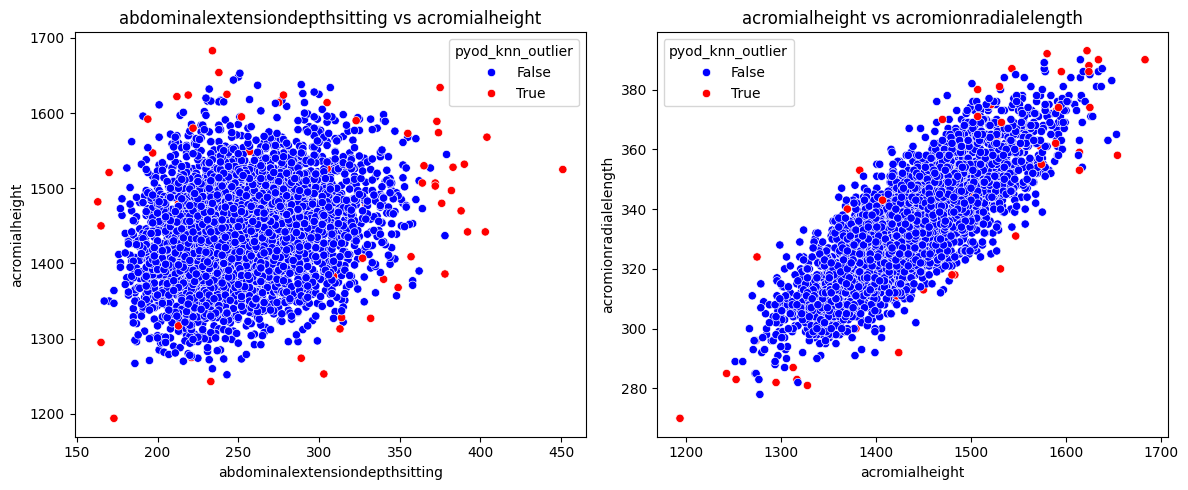

Total Outliers Detected: 60


In [31]:
# Initialize KNN model from PyOD
knn = KNN(n_neighbors=5, method='mean', contamination=0.05)  # 5% outliers
knn.fit(X_scaled)

# Get predictions (1 = outlier, 0 = inlier)
outlier_preds = knn.predict(X_scaled)

# Add outlier labels to DataFrame
df_selected['pyod_knn_outlier'] = outlier_preds.astype(bool)

# Print all detected outliers
outliers = df_selected[df_selected['pyod_knn_outlier']]
print("Detected Outliers:\n", outliers)

# Pairplot for multiple features (outliers in red)
sns.pairplot(df_selected, hue='pyod_knn_outlier', palette={True: "red", False: "blue"})
plt.suptitle("KNN Outlier Detection with PyOD", y=1.02)
plt.show()

# Scatter plots for selected feature pairs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pick first three numeric columns for visualization (modify as needed)
if len(numeric_cols) >= 3:
    feature_x, feature_y, feature_z = numeric_cols[:3]

    sns.scatterplot(x=df_selected[feature_x], y=df_selected[feature_y], 
                    hue=df_selected['pyod_knn_outlier'], palette={True: "red", False: "blue"}, ax=axes[0])
    axes[0].set_title(f"{feature_x} vs {feature_y}")

    sns.scatterplot(x=df_selected[feature_y], y=df_selected[feature_z], 
                    hue=df_selected['pyod_knn_outlier'], palette={True: "red", False: "blue"}, ax=axes[1])
    axes[1].set_title(f"{feature_y} vs {feature_z}")

    plt.tight_layout()
    plt.show()

# Print summary
print(f"Total Outliers Detected: {df_selected['pyod_knn_outlier'].sum()}")

In [24]:
# Get outlier probability scores
outlier_scores = knn.decision_function(X_scaled)  # Higher = more likely an outlier

# Normalize scores to [0, 1] range (probability)
outlier_probs = (outlier_scores - outlier_scores.min()) / (outlier_scores.max() - outlier_scores.min())

# Add results to DataFrame
df_selected['pyod_knn_outlier'] = outlier_preds.astype(bool)
df_selected['outlier_score'] = outlier_scores  # Raw anomaly score
df_selected['outlier_probability'] = outlier_probs  # Normalized probability

# Print top 10 most anomalous points
print(df_selected.sort_values(by="outlier_probability", ascending=False).head(10))


      abdominalextensiondepthsitting  acromialheight  pyod_knn_outlier  \
55                               451            1525              True   
2795                             173            1194              True   
1924                             375            1634              True   
118                              404            1568              True   
1414                             303            1253              True   
3172                             234            1683              True   
630                              403            1442              True   
1059                             165            1295              True   
1492                             378            1386              True   
1997                             378            1437              True   

      outlier_score  outlier_probability  
55         1.345719             1.000000  
2795       1.157474             0.859786  
1924       0.772290             0.572883  
118        0.